In [1]:
import numpy as np 
import pandas as pd 
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MinMaxScaler, Normalizer, RobustScaler, PolynomialFeatures
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, KFold
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression

from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor


pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

# Ignorer tous les avertissements (utilisez avec précaution)
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv('Data_Modelisation-3.csv')
df.rename(columns={'Vitesse' :'vitesse' ,'Moyenne G% [%]': 'glissement','Moyenne CFL C':"cflc"}, inplace=True)
df.vitesse = df.vitesse.astype(str)

X_o = df.drop(['Moyenne CFL F','Glissement',"hauteur (mm)", 'Fv (kg)', 'Tsurf (C)', 'T° BDR (C)'], axis=1)
#y = df['Moyenne CFL C']

In [3]:
X_o.Contaminant.value_counts()

Contaminant
NC.C.                232
Neige fraiche (B)    191
N.C. (B)             140
Neige fraiche (G)    129
Glace                107
N.C. (G)             106
SLUSH                 70
Verglas               58
DRY                   19
Name: count, dtype: int64

In [4]:
# Neige fraiche (B)
nfb = X_o[X_o.Contaminant == 'Neige fraiche (B)'].drop('Contaminant', axis = 1).copy().reset_index(drop = True)
# Neige fraiche (G)
nfg = X_o[X_o.Contaminant == 'Neige fraiche (G)'].drop('Contaminant', axis = 1).copy().reset_index(drop = True)
# N.C. (G)
ncg = X_o[X_o.Contaminant == 'N.C. (G)'].drop('Contaminant', axis = 1).copy().reset_index(drop = True)
# N.C. (B)
ncb = X_o[X_o.Contaminant == 'N.C. (B)'].drop('Contaminant', axis = 1).copy().reset_index(drop = True)
# NC.C.
ncc = X_o[X_o.Contaminant == 'NC.C.'].drop('Contaminant', axis = 1).copy().reset_index(drop = True)
# Verglas
ver = X_o[X_o.Contaminant == 'Verglas'].drop('Contaminant', axis = 1).copy().reset_index(drop = True)
# Glace
gla = X_o[X_o.Contaminant == 'Glace'].drop('Contaminant', axis = 1).copy().reset_index(drop = True)
# SLUSH
slh = X_o[X_o.Contaminant == 'SLUSH'].drop('Contaminant', axis = 1).copy().reset_index(drop = True)
# Columns to drop in every modele


In [5]:
l=[nfb, nfg, ncg, ncb, ncc, ver, gla, slh]
names = ['nfb', 'nfg', 'ncg', 'ncb', 'ncc', 'ver', 'gla', 'slh']
Contaminant = ['Neige fraiche (B)', 'Neige fraiche (G)', 'N.C. (G)', 'N.C. (B)', 'NC.C.', 'Verglas', 'Glace', 'SLUSH']
dict = {"Contaminant" : Contaminant, "Nombre d'observation" : list(map(lambda x: x.shape[0], l))}
pd.DataFrame(dict).sort_values(["Nombre d'observation"], ascending = False).reset_index(drop = True)

,Contaminant,Nombre d'observation
0,NC.C.,232
1,Neige fraiche (B),191
2,N.C. (B),140
3,Neige fraiche (G),129
4,Glace,107
5,N.C. (G),106
6,SLUSH,70
7,Verglas,58


In [6]:
def scale_encode(x,y = 0):
    encoder = OneHotEncoder(drop='first')
    # Séparer les variables qualitatives et numériques
    qualitative_vars = ['vitesse']
    numeric_vars = x.select_dtypes(include=['float']).columns.tolist()
    
    # Appliquer le one-hot encoding aux variables qualitatives
    encoded_vars = encoder.fit_transform(x[qualitative_vars]).toarray()
    encoded_columns = encoder.get_feature_names_out(qualitative_vars)
    encoded_df = pd.DataFrame(encoded_vars, columns=encoded_columns)
    if y == 1:  # Appliquer le StandardScaler aux variables numériques
        scaler = StandardScaler().set_output(transform='pandas')
    elif y == 2:  # Appliquer le Normalizer aux variables numériques
        scaler = Normalizer().set_output(transform='pandas')
    else:
        X = pd.concat([x.drop(['vitesse'], axis=1), encoded_df], axis=1)
        return X
    
    # Appliquer le scaler et transformer les variables numériques
    scaled_df = scaler.fit_transform(x[numeric_vars])
    
    # Concaténation des DataFrames encodé et standardisé
    X = pd.concat([scaled_df, encoded_df], axis=1)
    return X

## Neige fraiche (B)

In [7]:
def descritisation_nfb(x):
    if x< 6:
        return "6"
    elif x< 11:
        return "11"
    elif x< 14:
        return "14"
    elif x< 16:
        return "16"
    else:
        return "more"

In [9]:
data = nfb
X = data.drop(['cflc'], axis=1)
X = scale_encode(X,0)
y = data['cflc']




stratify_vitesse = X['vitesse_65']
stratify_glissement = X['glissement'].apply(descritisation_nfb)

# Créer une nouvelle colonne de stratification combinée
stratify_combined = stratify_vitesse.astype(str) + '_' + stratify_glissement.astype(str)


In [10]:
%%time
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=stratify_combined, random_state=37)
# Définition des grilles de recherche
param_grid_rf = {
    "random_state" : [46,50,55,59, 57,49],
    'n_estimators': [80, 100, 120],
    'max_depth': [4, 5],
    'min_samples_split': [2,3, 4],
    'min_samples_leaf': [1, 2]
}

param_grid_xgb = {
'n_estimators': [80, 100, 120],
"random_state" : [40,46,59,76,57,123,49],
'learning_rate': [0.05, 0.1],
'max_depth': [ 5, 10],
'min_child_weight': [1, 2],
'subsample': [0.8, 1.0],
'colsample_bytree': [0.8, 1.0]
}
# Initialisation de GridSearchCV avec validation croisée stratifiée
cv = KFold(n_splits=5, shuffle=True, random_state=42)
grid_rf = GridSearchCV(estimator=RandomForestRegressor(), param_grid=param_grid_rf, scoring='r2', cv=cv, n_jobs=-1)
grid_xgb = GridSearchCV(estimator=XGBRegressor(), param_grid=param_grid_xgb, scoring='r2', cv=cv, n_jobs=-1)

# Entraînement et évaluation des modèles avec validation croisée stratifiée
models = {
    "Random Forest": grid_rf,
    "XGBoost": grid_xgb
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    best_model = model.best_estimator_
    y_pred = best_model.predict(X_test)
    r2_test = r2_score(y_test, y_pred)
    results[name] = {
    "Best Params": model.best_params_,
    "R2 (Test)": round(r2_test, 4)
}


results_df = pd.DataFrame(results).T
print(results)
results_df


{'Random Forest': {'Best Params': {'max_depth': 4, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100, 'random_state': 57}, 'R2 (Test)': 0.8354}, 'XGBoost': {'Best Params': {'colsample_bytree': 1.0, 'learning_rate': 0.05, 'max_depth': 5, 'min_child_weight': 2, 'n_estimators': 80, 'random_state': 76, 'subsample': 0.8}, 'R2 (Test)': 0.854}}
CPU times: total: 8.59 s
Wall time: 45.8 s


,Best Params,R2 (Test)
Random Forest,"{'max_depth': 4, 'min_samples_leaf': 2, 'min_s...",0.8354
XGBoost,"{'colsample_bytree': 1.0, 'learning_rate': 0.0...",0.854


In [14]:
model =XGBRegressor(
    colsample_bytree=1,       # Fraction des caractéristiques utilisées (par défaut: 1.0)
    learning_rate= 0.05,       # Taux d'apprentissage (par défaut: 0.3)
    max_depth=5,             # Profondeur maximale de l'arbre (par défaut: 6)
    min_child_weight=2,       # Poids minimum d'une feuille (par défaut: 1)
    n_estimators=80,        # Nombre d'arbres de décision (par défaut: 100)
    random_state=76,
    subsample=0.8,            # Fraction des échantillons utilisés (par défaut: 1.0)
)


# Entraînement et évaluation des modèles
results = {}
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
results[name] = {"RMSE": round(np.sqrt(mse),4), "R2 Score": round(r2,4)}

results_df = pd.DataFrame(results).T
results_df

,R2 Score,RMSE
XGBoost,0.854,0.0133


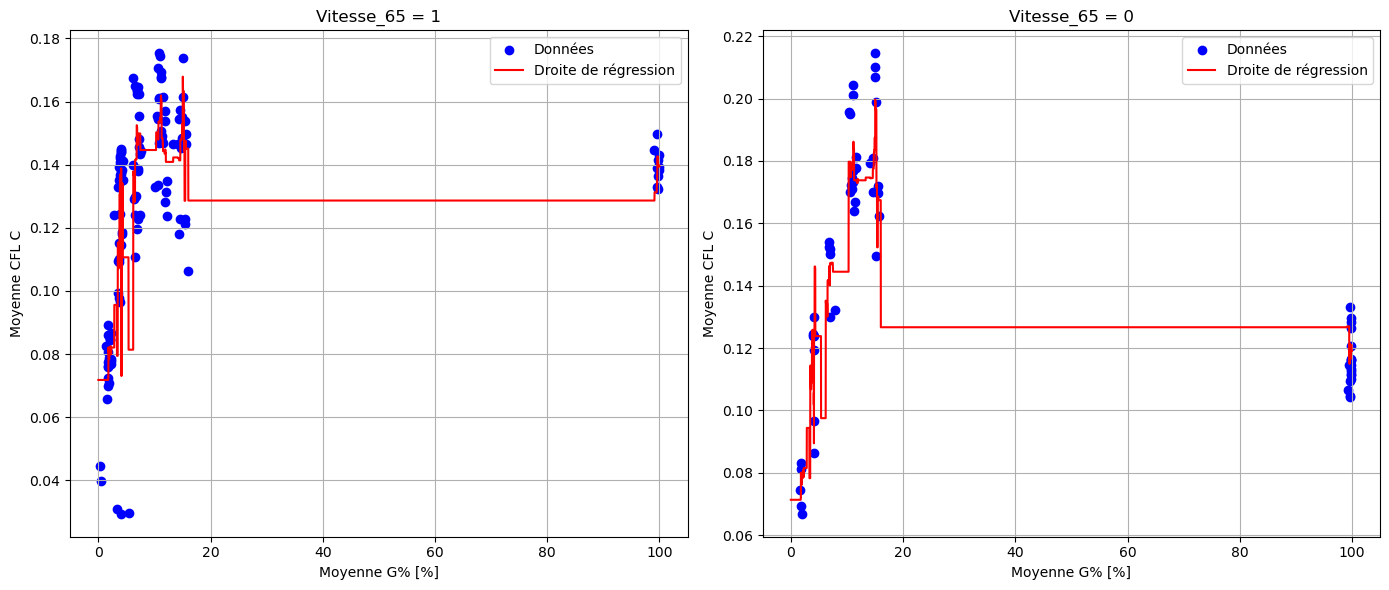

In [15]:
x = np.linspace(0, 100, 10000)
y_v1_regression = model.predict(pd.DataFrame({"glissement" : x,"vitesse_65" : 1}))
y1 = data[data["vitesse"] == "65"]['cflc']
# Calcul de la droite de régression pour Vitesse_65 = 0
y_v0_regression = model.predict(pd.DataFrame({"glissement" : x,"vitesse_65" : 0}))
y0 = data[data["vitesse"] == "40"]['cflc']



# Tracé des graphes
plt.figure(figsize=(14, 6))

# Graphique pour Vitesse_65 = 1
plt.subplot(1, 2, 1)
plt.scatter(X[X['vitesse_65']==1]['glissement'], y1, color='blue', label='Données')
plt.plot(x, y_v1_regression, color='red', label='Droite de régression')
plt.xlabel('Moyenne G% [%]')
plt.ylabel('Moyenne CFL C')
plt.title('Vitesse_65 = 1')
plt.legend()
plt.grid()

# Graphique pour Vitesse_65 = 0
plt.subplot(1, 2, 2)
plt.scatter(X[X['vitesse_65']==0]['glissement'], y0, color='blue', label='Données')
plt.plot(x, y_v0_regression, color='red', label='Droite de régression')
plt.xlabel('Moyenne G% [%]')
plt.ylabel('Moyenne CFL C')
plt.title('Vitesse_65 = 0')
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

## Neige fraiche (G)

In [16]:
def descritisation_nfg(x):
    if x<3:
        return "3"
    elif x< 6:
        return "6"
    elif x< 9:
        return "9"
    elif x< 13:
        return "13"
    elif x< 16:
        return "16"
    else:
        return "more"

In [17]:
data = nfg
X = data.drop(['cflc'], axis=1)

X = scale_encode(X,0)

y = data['cflc']




stratify_vitesse = X['vitesse_65']
stratify_glissement = X['glissement'].apply(descritisation_nfg)

# Créer une nouvelle colonne de stratification combinée
stratify_combined = stratify_vitesse.astype(str) + '_' + stratify_glissement.astype(str)


In [18]:
%%time
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=stratify_combined, random_state=29)
# Définition des grilles de recherche
param_grid_rf = {
    "random_state" : [59, 57,49],
    'n_estimators': [30, 40, 80, 100, 120],
    'max_depth': [4, 5],
    'min_samples_split': [2,3, 4],
    'min_samples_leaf': [1, 2]
}

param_grid_xgb = {
'n_estimators': [30 ,40,  60, 80],
"random_state" : [123,49,59],
'learning_rate': [0.05, 0.1],
'max_depth': [ 5, 10],
'min_child_weight': [1, 2],
'subsample': [0.8, 1.0],
'colsample_bytree': [0.8, 1.0]
}
# Initialisation de GridSearchCV avec validation croisée stratifiée
cv = KFold(n_splits=5, shuffle=True, random_state=0)
grid_rf = GridSearchCV(estimator=RandomForestRegressor(), param_grid=param_grid_rf, scoring='r2', cv=cv, n_jobs=-1)
grid_xgb = GridSearchCV(estimator=XGBRegressor(), param_grid=param_grid_xgb, scoring='r2', cv=cv, n_jobs=-1)

# Entraînement et évaluation des modèles avec validation croisée stratifiée
models = {
    "Random Forest": grid_rf,
    "XGBoost": grid_xgb
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    best_model = model.best_estimator_
    y_pred = best_model.predict(X_test)
    r2_test = r2_score(y_test, y_pred)
    y_pred_tr = best_model.predict(X_train)
    r2_train = r2_score(y_train, y_pred_tr)       
    results[name] = {
    "Best Params": model.best_params_,
    "R2 (Test)": round(r2_test, 4),
     "R2 (Train)" : round(r2_train, 4)
}


results_df = pd.DataFrame(results).T
print(results)
results_df


{'Random Forest': {'Best Params': {'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 3, 'n_estimators': 30, 'random_state': 49}, 'R2 (Test)': 0.9315, 'R2 (Train)': 0.9299}, 'XGBoost': {'Best Params': {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 5, 'min_child_weight': 2, 'n_estimators': 30, 'random_state': 49, 'subsample': 0.8}, 'R2 (Test)': 0.9323, 'R2 (Train)': 0.9498}}
CPU times: total: 4.19 s
Wall time: 20.3 s


,Best Params,R2 (Test),R2 (Train)
Random Forest,"{'max_depth': 5, 'min_samples_leaf': 1, 'min_s...",0.9315,0.9299
XGBoost,"{'colsample_bytree': 1.0, 'learning_rate': 0.1...",0.9323,0.9498


In [19]:
model =XGBRegressor(
    colsample_bytree=1,       # Fraction des caractéristiques utilisées (par défaut: 1.0)
    learning_rate= 0.1,       # Taux d'apprentissage (par défaut: 0.3)
    max_depth=5,             # Profondeur maximale de l'arbre (par défaut: 6)
    min_child_weight=2,       # Poids minimum d'une feuille (par défaut: 1)
    n_estimators=30,        # Nombre d'arbres de décision (par défaut: 100)
    random_state=49,
    subsample=0.8,            # Fraction des échantillons utilisés (par défaut: 1.0)
)


# Entraînement et évaluation des modèles
results = {}
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
results[name] = {"RMSE": round(np.sqrt(mse),4), "R2 Score": round(r2,4)}

results_df = pd.DataFrame(results).T
results_df

,R2 Score,RMSE
XGBoost,0.9323,0.0106


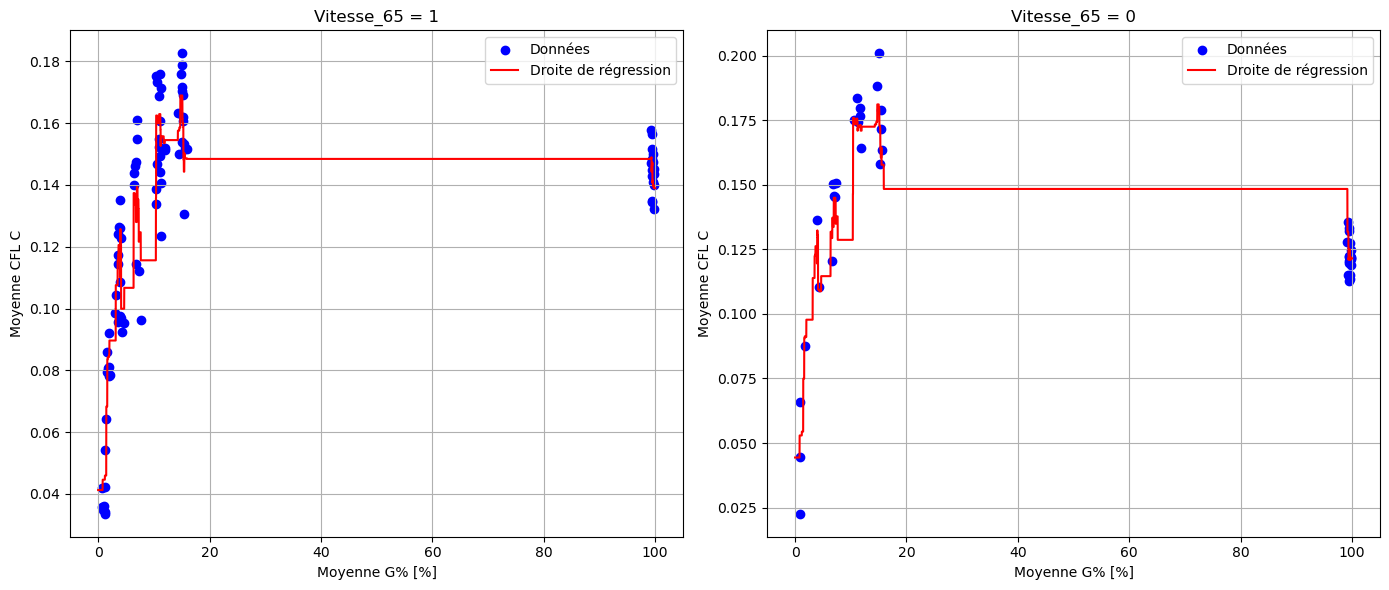

In [20]:
x = np.linspace(0, 100, 10000)
y_v1_regression = model.predict(pd.DataFrame({"glissement" : x, "vitesse_65" : 1}))
y1 = data[data["vitesse"] == "65"]['cflc']
# Calcul de la droite de régression pour Vitesse_65 = 0
y_v0_regression = model.predict(pd.DataFrame({"glissement" : x, "vitesse_65" : 0}))
y0 = data[data["vitesse"] == "40"]['cflc']



# Tracé des graphes
plt.figure(figsize=(14, 6))

# Graphique pour Vitesse_65 = 1
plt.subplot(1, 2, 1)
plt.scatter(X[X['vitesse_65']==1]['glissement'], y1, color='blue', label='Données')
plt.plot(x, y_v1_regression, color='red', label='Droite de régression')
plt.xlabel('Moyenne G% [%]')
plt.ylabel('Moyenne CFL C')
plt.title('Vitesse_65 = 1')
plt.legend()
plt.grid()

# Graphique pour Vitesse_65 = 0
plt.subplot(1, 2, 2)
plt.scatter(X[X['vitesse_65']==0]['glissement'], y0, color='blue', label='Données')
plt.plot(x, y_v0_regression, color='red', label='Droite de régression')
plt.xlabel('Moyenne G% [%]')
plt.ylabel('Moyenne CFL C')
plt.title('Vitesse_65 = 0')
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

## N.C. (G)

In [7]:
def descritisation_ncg(x):
    if x<2:
        return "2"
    elif x< 5:
        return "5"
    elif x< 9:
        return "9"
    elif x< 12:
        return "12"
    elif x< 15:
        return "15"
    elif x< 17:
        return "17"
    else:
        return "more"

In [8]:
data = ncg
X = data.drop(['cflc'], axis=1)

X = scale_encode(X,0)

y = data['cflc']




stratify_vitesse = X['vitesse_65']
stratify_glissement = X['glissement'].apply(descritisation_ncg)

# Créer une nouvelle colonne de stratification combinée
stratify_combined = stratify_vitesse.astype(str) + '_' + stratify_glissement.astype(str)


In [10]:
%%time
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=stratify_combined, random_state=40)
# Définition des grilles de recherche
param_grid_rf = {
    "random_state" : [2,40,60, 49],
    'n_estimators': [30, 40, 80, 100, 120],
    'max_depth': [4, 5],
    'min_samples_split': [2,3, 4],
    'min_samples_leaf': [1, 2]
}

param_grid_xgb = {
'n_estimators': [30 ,40,  60, 80],
"random_state" : [2, 42,40,60, 123],
'learning_rate': [0.05, 0.1],
'max_depth': [ 5, 10],
'min_child_weight': [1, 2],
'subsample': [0.7,0.8,0.9, 1.0],
'colsample_bytree': [0.7,0.8,0.9, 1.0]
}
# Initialisation de GridSearchCV avec validation croisée stratifiée
cv = KFold(n_splits=5, shuffle=True, random_state=0)
grid_rf = GridSearchCV(estimator=RandomForestRegressor(), param_grid=param_grid_rf, scoring='r2', cv=cv, n_jobs=-1)
grid_xgb = GridSearchCV(estimator=XGBRegressor(), param_grid=param_grid_xgb, scoring='r2', cv=cv, n_jobs=-1)

# Entraînement et évaluation des modèles avec validation croisée stratifiée
models = {
    "Random Forest": grid_rf,
    "XGBoost": grid_xgb
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    best_model = model.best_estimator_
    y_pred = best_model.predict(X_test)
    r2_test = r2_score(y_test, y_pred)
    y_pred_tr = best_model.predict(X_train)
    r2_train = r2_score(y_train, y_pred_tr)       
    results[name] = {
    "Best Params": model.best_params_,
    "R2 (Test)": round(r2_test, 4),
     "R2 (Train)" : round(r2_train, 4)
}


results_df = pd.DataFrame(results).T
print(results)
results_df


{'Random Forest': {'Best Params': {'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 30, 'random_state': 60}, 'R2 (Test)': 0.9185, 'R2 (Train)': 0.9547}, 'XGBoost': {'Best Params': {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 5, 'min_child_weight': 2, 'n_estimators': 30, 'random_state': 42, 'subsample': 0.7}, 'R2 (Test)': 0.935, 'R2 (Train)': 0.9622}}
CPU times: total: 19.3 s
Wall time: 1min 7s


,Best Params,R2 (Test),R2 (Train)
Random Forest,"{'max_depth': 5, 'min_samples_leaf': 2, 'min_s...",0.9185,0.9547
XGBoost,"{'colsample_bytree': 1.0, 'learning_rate': 0.1...",0.935,0.9622


In [13]:
model =XGBRegressor(
    colsample_bytree=1,       # Fraction des caractéristiques utilisées (par défaut: 1.0)
    learning_rate= 0.1,       # Taux d'apprentissage (par défaut: 0.3)
    max_depth=5,             # Profondeur maximale de l'arbre (par défaut: 6)
    min_child_weight=2,       # Poids minimum d'une feuille (par défaut: 1)
    n_estimators=30,        # Nombre d'arbres de décision (par défaut: 100)
    random_state=42,
    subsample=0.7,            # Fraction des échantillons utilisés (par défaut: 1.0)
)


# Entraînement et évaluation des modèles
results = {}
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
results[name] = {"RMSE": round(np.sqrt(mse),4), "R2 Score": round(r2,4)}

results_df = pd.DataFrame(results).T
results_df

,R2 Score,RMSE
XGBoost,0.935,0.0152


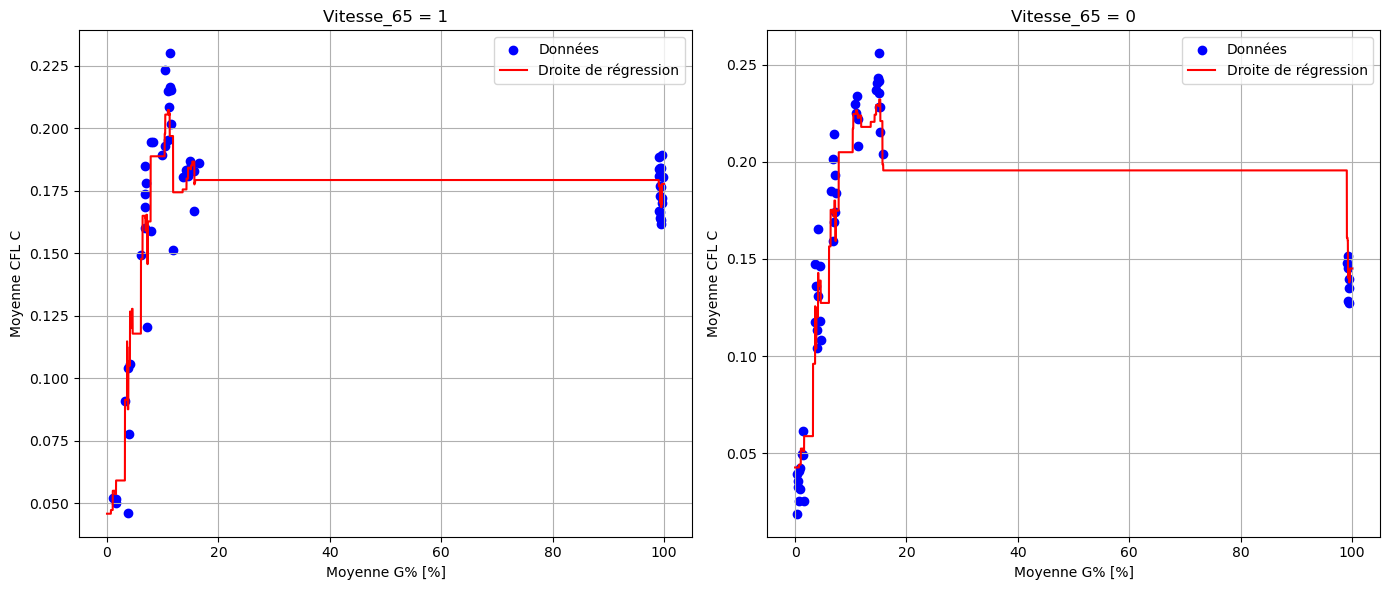

In [14]:
x = np.linspace(0, 100, 10000)
y_v1_regression = model.predict(pd.DataFrame({"glissement" : x, "vitesse_65" : 1}))
y1 = data[data["vitesse"] == "65"]['cflc']
# Calcul de la droite de régression pour Vitesse_65 = 0
y_v0_regression = model.predict(pd.DataFrame({"glissement" : x, "vitesse_65" : 0}))
y0 = data[data["vitesse"] == "40"]['cflc']



# Tracé des graphes
plt.figure(figsize=(14, 6))

# Graphique pour Vitesse_65 = 1
plt.subplot(1, 2, 1)
plt.scatter(X[X['vitesse_65']==1]['glissement'], y1, color='blue', label='Données')
plt.plot(x, y_v1_regression, color='red', label='Droite de régression')
plt.xlabel('Moyenne G% [%]')
plt.ylabel('Moyenne CFL C')
plt.title('Vitesse_65 = 1')
plt.legend()
plt.grid()

# Graphique pour Vitesse_65 = 0
plt.subplot(1, 2, 2)
plt.scatter(X[X['vitesse_65']==0]['glissement'], y0, color='blue', label='Données')
plt.plot(x, y_v0_regression, color='red', label='Droite de régression')
plt.xlabel('Moyenne G% [%]')
plt.ylabel('Moyenne CFL C')
plt.title('Vitesse_65 = 0')
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

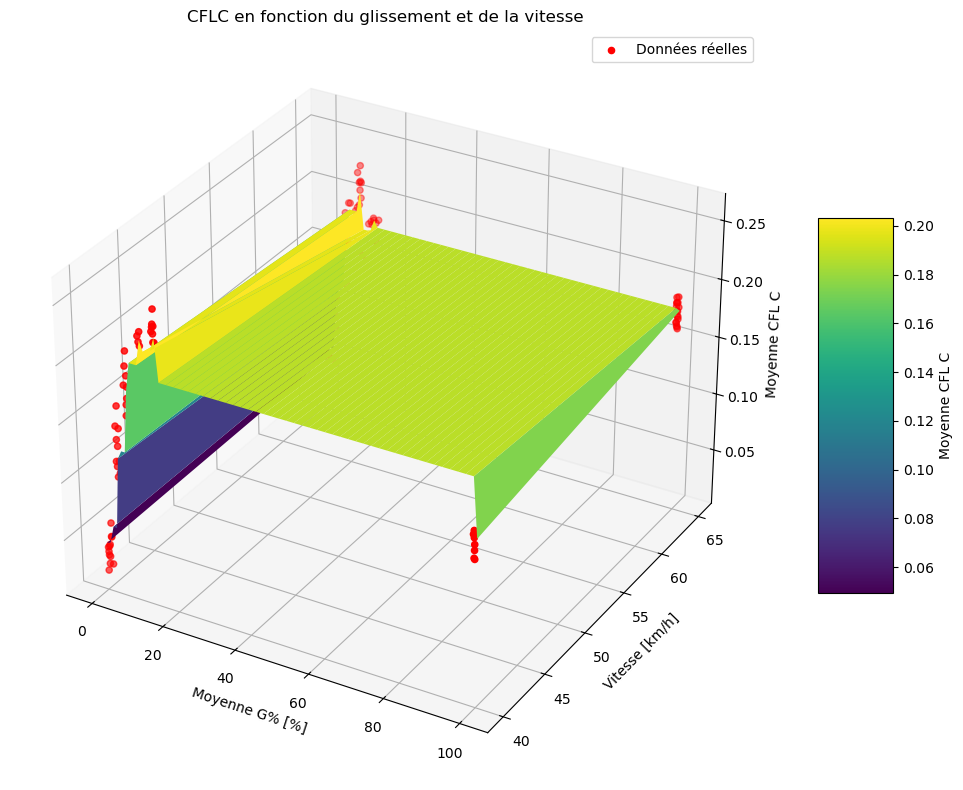

In [15]:
from mpl_toolkits.mplot3d import Axes3D

# Create a meshgrid for glissement and vitesse
glissement = np.linspace(0, 100, 100)
vitesse = np.linspace(40, 65, 2)
glissement_mesh, vitesse_mesh = np.meshgrid(glissement, vitesse)

# Prepare the input data for prediction
X_pred = pd.DataFrame({
    "glissement": glissement_mesh.ravel(),
    "vitesse_65": (vitesse_mesh.ravel() == 65).astype(int)
})

# Predict CFLC values
cflc_pred = model.predict(X_pred).reshape(vitesse_mesh.shape)

# Create the 3D plot
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot the surface
surf = ax.plot_surface(glissement_mesh, vitesse_mesh, cflc_pred, cmap='viridis')

# Plot the actual data points
vitesse_actual = data['vitesse'].replace({'40': 40, '65': 65}).astype(float)
ax.scatter(data['glissement'], vitesse_actual, data['cflc'], color='red', s=20, label='Données réelles')

# Customize the plot
ax.set_xlabel('Moyenne G% [%]')
ax.set_ylabel('Vitesse [km/h]')
ax.set_zlabel('Moyenne CFL C')
ax.set_title('CFLC en fonction du glissement et de la vitesse')

# Add a color bar
fig.colorbar(surf, ax=ax, shrink=0.5, aspect=5, label='Moyenne CFL C')

# Add legend
ax.legend()

plt.tight_layout()
plt.show()

## N.C. (B)

In [44]:
def descritisation_ncb(x):
    if x<2:
        return "2"
    elif x< 5:
        return "5"
    elif x< 9:
        return "9"
    elif x< 12:
        return "12"
    elif x< 15:
        return "15"
    elif x< 17:
        return "17"
    else:
        return "more"

In [45]:
data = ncb
X = data.drop(['cflc'], axis=1)

X = scale_encode(X,0)

y = data['cflc']




stratify_vitesse = X['vitesse_65']
stratify_glissement = X['glissement'].apply(descritisation_ncb)

# Créer une nouvelle colonne de stratification combinée
stratify_combined = stratify_vitesse.astype(str) + '_' + stratify_glissement.astype(str)


In [46]:
%%time
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=stratify_combined, random_state=123)
# Définition des grilles de recherche
param_grid_rf = {
    "random_state" : [2,40,60, 49],
    'n_estimators': [30, 40, 80, 100, 120],
    'max_depth': [4, 5],
    'min_samples_split': [2,3, 4],
    'min_samples_leaf': [1, 2]
}

param_grid_xgb = {
'n_estimators': [30 ,40,  60, 80],
"random_state" : [2, 42,40,60, 123],
'learning_rate': [0.05, 0.1],
'max_depth': [ 5, 10],
'min_child_weight': [1, 2],
'subsample': [0.8, 1.0],
'colsample_bytree': [0.8, 1.0]
}
# Initialisation de GridSearchCV avec validation croisée stratifiée
cv = KFold(n_splits=5, shuffle=True, random_state=0)
grid_rf = GridSearchCV(estimator=RandomForestRegressor(), param_grid=param_grid_rf, scoring='r2', cv=cv, n_jobs=-1)
grid_xgb = GridSearchCV(estimator=XGBRegressor(), param_grid=param_grid_xgb, scoring='r2', cv=cv, n_jobs=-1)

# Entraînement et évaluation des modèles avec validation croisée stratifiée
models = {
    "Random Forest": grid_rf,
    "XGBoost": grid_xgb
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    best_model = model.best_estimator_
    y_pred = best_model.predict(X_test)
    r2_test = r2_score(y_test, y_pred)
    y_pred_tr = best_model.predict(X_train)
    r2_train = r2_score(y_train, y_pred_tr)       
    results[name] = {
    "Best Params": model.best_params_,
    "R2 (Test)": round(r2_test, 4),
     "R2 (Train)" : round(r2_train, 4)
}


results_df = pd.DataFrame(results).T
print(results)
results_df


{'Random Forest': {'Best Params': {'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 3, 'n_estimators': 40, 'random_state': 60}, 'R2 (Test)': 0.9235, 'R2 (Train)': 0.937}, 'XGBoost': {'Best Params': {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 5, 'min_child_weight': 2, 'n_estimators': 30, 'random_state': 60, 'subsample': 0.8}, 'R2 (Test)': 0.9022, 'R2 (Train)': 0.9466}}
CPU times: total: 6.91 s
Wall time: 30.8 s


,Best Params,R2 (Test),R2 (Train)
Random Forest,"{'max_depth': 5, 'min_samples_leaf': 1, 'min_s...",0.9235,0.937
XGBoost,"{'colsample_bytree': 1.0, 'learning_rate': 0.1...",0.9022,0.9466


In [51]:
model = RandomForestRegressor(
    max_depth=5,             # Profondeur maximale de l'arbre
    min_samples_leaf=1,      # Nombre minimum d'échantillons par feuille
    min_samples_split=3,     # Nombre minimum d'échantillons pour diviser un nœud
    n_estimators=40,         # Nombre d'arbres dans la forêt
    random_state=60           # État aléatoire pour la reproductibilité
)


# Entraînement et évaluation des modèles
results = {}
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
results[name] = {"RMSE": round(np.sqrt(mse),4), "R2 Score": round(r2,4)}

results_df = pd.DataFrame(results).T
results_df

,R2 Score,RMSE
XGBoost,0.9235,0.0166


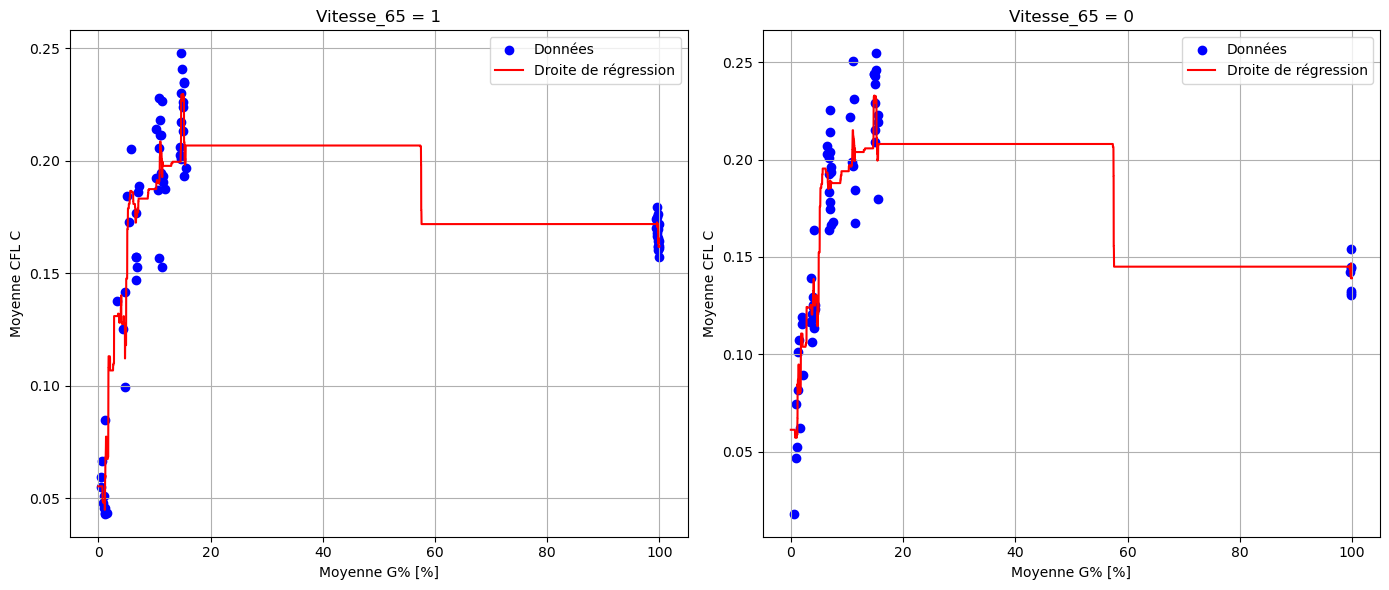

In [52]:
x = np.linspace(0, 100, 10000)
y_v1_regression = model.predict(pd.DataFrame({"glissement" : x, "vitesse_65" : 1}))
y1 = data[data["vitesse"] == "65"]['cflc']
# Calcul de la droite de régression pour Vitesse_65 = 0
y_v0_regression = model.predict(pd.DataFrame({"glissement" : x, "vitesse_65" : 0}))
y0 = data[data["vitesse"] == "40"]['cflc']



# Tracé des graphes
plt.figure(figsize=(14, 6))

# Graphique pour Vitesse_65 = 1
plt.subplot(1, 2, 1)
plt.scatter(X[X['vitesse_65']==1]['glissement'], y1, color='blue', label='Données')
plt.plot(x, y_v1_regression, color='red', label='Droite de régression')
plt.xlabel('Moyenne G% [%]')
plt.ylabel('Moyenne CFL C')
plt.title('Vitesse_65 = 1')
plt.legend()
plt.grid()

# Graphique pour Vitesse_65 = 0
plt.subplot(1, 2, 2)
plt.scatter(X[X['vitesse_65']==0]['glissement'], y0, color='blue', label='Données')
plt.plot(x, y_v0_regression, color='red', label='Droite de régression')
plt.xlabel('Moyenne G% [%]')
plt.ylabel('Moyenne CFL C')
plt.title('Vitesse_65 = 0')
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

## NC.C.

In [53]:
def descritisation_ncc(x):
    if x<2:
        return "2"
    if x<4:
        return "4"
    if x<6:
        return "6"
    elif x< 8:
        return "8"
    elif x< 11:
        return "11"
    elif x< 14:
        return "14"
    elif x< 16:
        return "16"
    else:
        return "more"

In [85]:
data = ncc
X = data.drop(['cflc'], axis=1)
X = scale_encode(X,0)
y = data['cflc']




stratify_vitesse = X['vitesse_65']
stratify_glissement = X['glissement'].apply(descritisation_ncc)

# Créer une nouvelle colonne de stratification combinée
stratify_combined = stratify_vitesse.astype(str) + '_' + stratify_glissement.astype(str)

In [86]:
%%time
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=stratify_combined, random_state=16)
# Définition des grilles de recherche
param_grid_rf = {
    "random_state" : [2,40,60, 49,0],
    'n_estimators': [30, 40, 80, 100, 120,130],
    'max_depth': [2, 4, 5],
    'min_samples_split': [2,3, 4],
    'min_samples_leaf': [1, 2]
}

param_grid_xgb = {
'n_estimators': [35, 30 ,40,  60, 80, 100],
"random_state" : [2, 42,40,60, 123, 0],
'learning_rate': [0.05, 0.1,0.095, 0.15, 0.001],
'max_depth': [ 5, 10],
'min_child_weight': [1, 2, 3],
'subsample': [0.7, 0.75,0.8, 1.0],
'colsample_bytree': [0.7, 0.75,0.8, 1.0]
}
# Initialisation de GridSearchCV avec validation croisée stratifiée
cv = KFold(n_splits=5, shuffle=True, random_state=0)
grid_rf = GridSearchCV(estimator=RandomForestRegressor(), param_grid=param_grid_rf, scoring='r2', cv=cv, n_jobs=-1)
grid_xgb = GridSearchCV(estimator=XGBRegressor(), param_grid=param_grid_xgb, scoring='r2', cv=cv, n_jobs=-1)

# Entraînement et évaluation des modèles avec validation croisée stratifiée
models = {
    "Random Forest": grid_rf,
    "XGBoost": grid_xgb
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    best_model = model.best_estimator_
    y_pred = best_model.predict(X_test)
    r2_test = r2_score(y_test, y_pred)
    y_pred_tr = best_model.predict(X_train)
    r2_train = r2_score(y_train, y_pred_tr)       
    results[name] = {
    "Best Params": model.best_params_,
    "R2 (Test)": round(r2_test, 4),
     "R2 (Train)" : round(r2_train, 4)
}


results_df = pd.DataFrame(results).T
print(results)
results_df


{'Random Forest': {'Best Params': {'max_depth': 4, 'min_samples_leaf': 1, 'min_samples_split': 3, 'n_estimators': 120, 'random_state': 2}, 'R2 (Test)': 0.9236, 'R2 (Train)': 0.8786}, 'XGBoost': {'Best Params': {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 5, 'min_child_weight': 2, 'n_estimators': 30, 'random_state': 2, 'subsample': 0.7}, 'R2 (Test)': 0.9151, 'R2 (Train)': 0.9113}}
CPU times: total: 1min 53s
Wall time: 5min 32s


,Best Params,R2 (Test),R2 (Train)
Random Forest,"{'max_depth': 4, 'min_samples_leaf': 1, 'min_s...",0.9236,0.8786
XGBoost,"{'colsample_bytree': 1.0, 'learning_rate': 0.1...",0.9151,0.9113


In [87]:
model =XGBRegressor(
    colsample_bytree=1,       # Fraction des caractéristiques utilisées (par défaut: 1.0)
    learning_rate= 0.1,       # Taux d'apprentissage (par défaut: 0.3)
    max_depth=5,             # Profondeur maximale de l'arbre (par défaut: 6)
    min_child_weight=2,       # Poids minimum d'une feuille (par défaut: 1)
    n_estimators=30,        # Nombre d'arbres de décision (par défaut: 100)
    random_state=2,
    subsample=0.7,            # Fraction des échantillons utilisés (par défaut: 1.0)
)


# Entraînement et évaluation des modèles
results = {}
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
results[name] = {"RMSE": round(np.sqrt(mse),4), "R2 Score": round(r2,4)}

results_df = pd.DataFrame(results).T
results_df

,R2 Score,RMSE
XGBoost,0.9151,0.0165


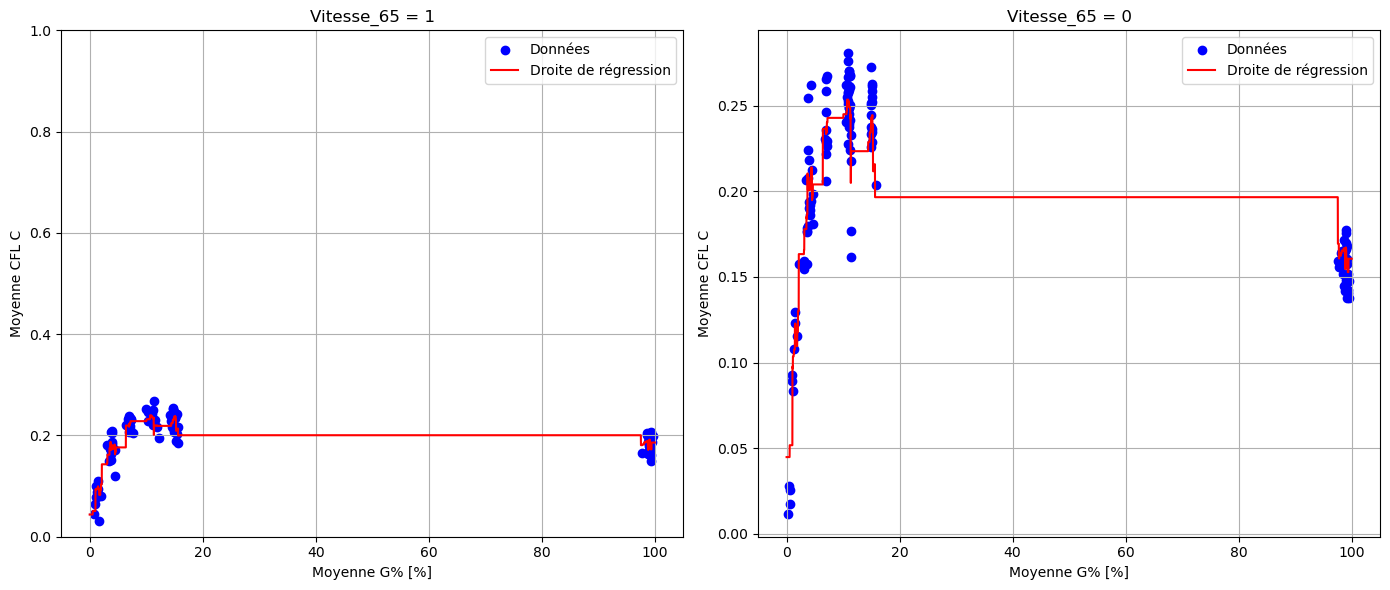

In [88]:
x = np.linspace(0, 100, 10000)
y_v1_regression = model.predict(pd.DataFrame({"glissement" : x, "vitesse_65" : 1}))
y1 = data[data["vitesse"] == "65"]['cflc']
# Calcul de la droite de régression pour Vitesse_65 = 0
y_v0_regression = model.predict(pd.DataFrame({"glissement" : x, "vitesse_65" : 0}))
y0 = data[data["vitesse"] == "40"]['cflc']



# Tracé des graphes
plt.figure(figsize=(14, 6))

# Graphique pour Vitesse_65 = 1
plt.subplot(1, 2, 1)
plt.scatter(X[X['vitesse_65']==1]['glissement'], y1, color='blue', label='Données')
plt.plot(x, y_v1_regression, color='red', label='Droite de régression')
plt.xlabel('Moyenne G% [%]')
plt.ylabel('Moyenne CFL C')
plt.title('Vitesse_65 = 1')
plt.ylim(0, 1)

plt.legend()
plt.grid()

# Graphique pour Vitesse_65 = 0
plt.subplot(1, 2, 2)
plt.scatter(X[X['vitesse_65']==0]['glissement'], y0, color='blue', label='Données')
plt.plot(x, y_v0_regression, color='red', label='Droite de régression')
plt.xlabel('Moyenne G% [%]')
plt.ylabel('Moyenne CFL C')
plt.title('Vitesse_65 = 0')
# plt.ylim(0, 1)
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

## Verglas

In [57]:
def descritisation_verglas(x):
    if x<2:
        return "2"
    if x<5:
        return "5"
    if x<11:
        return "11"
    elif x< 13:
        return "13"
    elif x< 17:
        return "17"
    else:
        return "more"

In [58]:
data = ver
X = data.drop(['cflc'], axis=1)
X = scale_encode(X,0)
y = data['cflc']




stratify_vitesse = X['vitesse_65']
stratify_glissement = X['glissement'].apply(descritisation_verglas)

# Créer une nouvelle colonne de stratification combinée
stratify_combined = stratify_vitesse.astype(str) + '_' + stratify_glissement.astype(str)


In [59]:
%%time
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=stratify_combined, random_state=19)
# Définition des grilles de recherche
param_grid_rf = {
    "random_state" : [2,40,60, 49,0],
    'n_estimators': [30, 40, 80, 100, 120,130],
    'max_depth': [2, 4, 5],
    'min_samples_split': [2,3, 4],
    'min_samples_leaf': [1, 2]
}

param_grid_xgb = {
'n_estimators': [35, 30 ,40,  60, 80, 100],
"random_state" : [2, 42,40,60, 123, 0],
'learning_rate': [0.05, 0.1,0.095, 0.15, 0.001],
'max_depth': [ 5, 10],
'min_child_weight': [1, 2, 3],
'subsample': [0.7, 0.75,0.8, 1.0],
'colsample_bytree': [0.7, 0.75,0.8, 1.0]
}
# Initialisation de GridSearchCV avec validation croisée stratifiée
cv = KFold(n_splits=5, shuffle=True, random_state=0)
grid_rf = GridSearchCV(estimator=RandomForestRegressor(), param_grid=param_grid_rf, scoring='r2', cv=cv, n_jobs=-1)
grid_xgb = GridSearchCV(estimator=XGBRegressor(), param_grid=param_grid_xgb, scoring='r2', cv=cv, n_jobs=-1)

# Entraînement et évaluation des modèles avec validation croisée stratifiée
models = {
    "Random Forest": grid_rf,
    "XGBoost": grid_xgb
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    best_model = model.best_estimator_
    y_pred = best_model.predict(X_test)
    r2_test = r2_score(y_test, y_pred)
    y_pred_tr = best_model.predict(X_train)
    r2_train = r2_score(y_train, y_pred_tr)       
    results[name] = {
    "Best Params": model.best_params_,
    "R2 (Test)": round(r2_test, 4),
     "R2 (Train)" : round(r2_train, 4)
}


results_df = pd.DataFrame(results).T
print(results)
results_df


{'Random Forest': {'Best Params': {'max_depth': 2, 'min_samples_leaf': 1, 'min_samples_split': 4, 'n_estimators': 80, 'random_state': 40}, 'R2 (Test)': 0.8349, 'R2 (Train)': 0.8541}, 'XGBoost': {'Best Params': {'colsample_bytree': 1.0, 'learning_rate': 0.095, 'max_depth': 5, 'min_child_weight': 1, 'n_estimators': 35, 'random_state': 42, 'subsample': 0.7}, 'R2 (Test)': 0.8411, 'R2 (Train)': 0.965}}
CPU times: total: 1min 49s
Wall time: 4min 30s


,Best Params,R2 (Test),R2 (Train)
Random Forest,"{'max_depth': 2, 'min_samples_leaf': 1, 'min_s...",0.8349,0.8541
XGBoost,"{'colsample_bytree': 1.0, 'learning_rate': 0.0...",0.8411,0.965


In [68]:
model =XGBRegressor(
    colsample_bytree=1,       # Fraction des caractéristiques utilisées (par défaut: 1.0)
    learning_rate= 0.095,       # Taux d'apprentissage (par défaut: 0.3)
    max_depth=5,             # Profondeur maximale de l'arbre (par défaut: 6)
    min_child_weight=1,       # Poids minimum d'une feuille (par défaut: 1)
    n_estimators=35,        # Nombre d'arbres de décision (par défaut: 100)
    random_state=42,
    subsample=0.7,            # Fraction des échantillons utilisés (par défaut: 1.0)
)


# Entraînement et évaluation des modèles
results = {}
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
results[name] = {"RMSE": round(np.sqrt(mse),4), "R2 Score": round(r2,4)}

results_df = pd.DataFrame(results).T
results_df

,R2 Score,RMSE
XGBoost,0.9004,0.0214


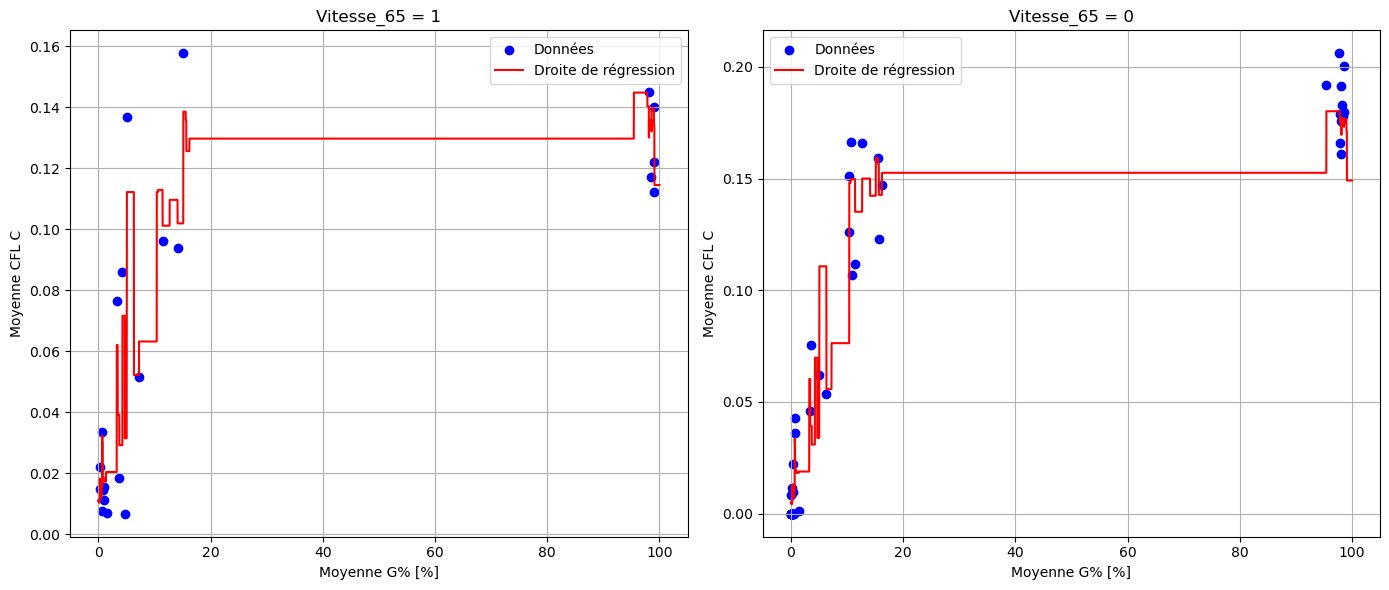

In [69]:
x = np.linspace(0, 100, 10000)
y_v1_regression = model.predict(pd.DataFrame({"glissement" : x, "vitesse_65" : 1}))
y1 = data[data["vitesse"] == "65"]['cflc']
# Calcul de la droite de régression pour Vitesse_65 = 0
y_v0_regression = model.predict(pd.DataFrame({"glissement" : x, "vitesse_65" : 0}))
y0 = data[data["vitesse"] == "40"]['cflc']



# Tracé des graphes
plt.figure(figsize=(14, 6))

# Graphique pour Vitesse_65 = 1
plt.subplot(1, 2, 1)
plt.scatter(X[X['vitesse_65']==1]['glissement'], y1, color='blue', label='Données')
plt.plot(x, y_v1_regression, color='red', label='Droite de régression')
plt.xlabel('Moyenne G% [%]')
plt.ylabel('Moyenne CFL C')
plt.title('Vitesse_65 = 1')
plt.legend()
plt.grid()

# Graphique pour Vitesse_65 = 0
plt.subplot(1, 2, 2)
plt.scatter(X[X['vitesse_65']==0]['glissement'], y0, color='blue', label='Données')
plt.plot(x, y_v0_regression, color='red', label='Droite de régression')
plt.xlabel('Moyenne G% [%]')
plt.ylabel('Moyenne CFL C')
plt.title('Vitesse_65 = 0')
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

## Glace

In [60]:
def descritisation_glace(x):
    if x<3:
        return "3"
    if x<4:
        return "4"
    if x<6:
        return "6"
    if x<8:
        return "8"
    if x<11:
        return "11"
    elif x< 13:
        return "13"
    elif x< 15:
        return "15"
    elif x< 17:
        return "17"
    else:
        return "more"

In [61]:
data = gla
X = data.drop(['cflc'], axis=1)
X = scale_encode(X,0)
y = data['cflc']




stratify_vitesse = X['vitesse_65']
stratify_glissement = X['glissement'].apply(descritisation_glace)

# Créer une nouvelle colonne de stratification combinée
stratify_combined = stratify_vitesse.astype(str) + '_' + stratify_glissement.astype(str)


In [64]:
%%time
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=stratify_combined, random_state=17)
# Définition des grilles de recherche

param_grid_rf = {
    "random_state" : [2,40,60, 49,0],
    'n_estimators': [30, 40, 80, 100, 120,130],
    'max_depth': [2, 4, 5],
    'min_samples_split': [2,3, 4],
    'min_samples_leaf': [1, 2]
}

param_grid_xgb = {
'n_estimators': [35, 30 ,40,  60, 80, 100],
"random_state" : [2, 42,40,60, 123, 0],
'learning_rate': [0.05, 0.1,0.095, 0.15, 0.001],
'max_depth': [3, 4, 5, 10],
'min_child_weight': [1, 2, 3],
'subsample': [0.7, 0.75,0.8, 1.0],
'colsample_bytree': [0.7, 0.75,0.8, 1.0]
}
# Initialisation de GridSearchCV avec validation croisée stratifiée
cv = KFold(n_splits=5, shuffle=True, random_state=0)
grid_rf = GridSearchCV(estimator=RandomForestRegressor(), param_grid=param_grid_rf, scoring='r2', cv=cv, n_jobs=-1)
grid_xgb = GridSearchCV(estimator=XGBRegressor(), param_grid=param_grid_xgb, scoring='r2', cv=cv, n_jobs=-1)

# Entraînement et évaluation des modèles avec validation croisée stratifiée
models = {
    "Random Forest": grid_rf,
    "XGBoost": grid_xgb
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    best_model = model.best_estimator_
    y_pred = best_model.predict(X_test)
    r2_test = r2_score(y_test, y_pred)
    y_pred_tr = best_model.predict(X_train)
    r2_train = r2_score(y_train, y_pred_tr)       
    results[name] = {
    "Best Params": model.best_params_,
    "R2 (Test)": round(r2_test, 4),
     "R2 (Train)" : round(r2_train, 4)
}


results_df = pd.DataFrame(results).T
print(results)
results_df


{'Random Forest': {'Best Params': {'max_depth': 4, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 30, 'random_state': 2}, 'R2 (Test)': 0.9442, 'R2 (Train)': 0.9194}, 'XGBoost': {'Best Params': {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 4, 'min_child_weight': 3, 'n_estimators': 30, 'random_state': 60, 'subsample': 0.7}, 'R2 (Test)': 0.9451, 'R2 (Train)': 0.9348}}
CPU times: total: 3min 34s
Wall time: 8min 12s


,Best Params,R2 (Test),R2 (Train)
Random Forest,"{'max_depth': 4, 'min_samples_leaf': 2, 'min_s...",0.9442,0.9194
XGBoost,"{'colsample_bytree': 1.0, 'learning_rate': 0.1...",0.9451,0.9348


In [70]:
model =XGBRegressor(
    colsample_bytree=1,       # Fraction des caractéristiques utilisées (par défaut: 1.0)
    learning_rate= 0.1,       # Taux d'apprentissage (par défaut: 0.3)
    max_depth=4,             # Profondeur maximale de l'arbre (par défaut: 6)
    min_child_weight=3,       # Poids minimum d'une feuille (par défaut: 1)
    n_estimators=30,        # Nombre d'arbres de décision (par défaut: 100)
    random_state=60,
    subsample=0.7,            # Fraction des échantillons utilisés (par défaut: 1.0)
)


# Entraînement et évaluation des modèles
results = {}
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
results[name] = {"RMSE": round(np.sqrt(mse),4), "R2 Score": round(r2,4)}

results_df = pd.DataFrame(results).T
results_df

,R2 Score,RMSE
XGBoost,0.918,0.0194


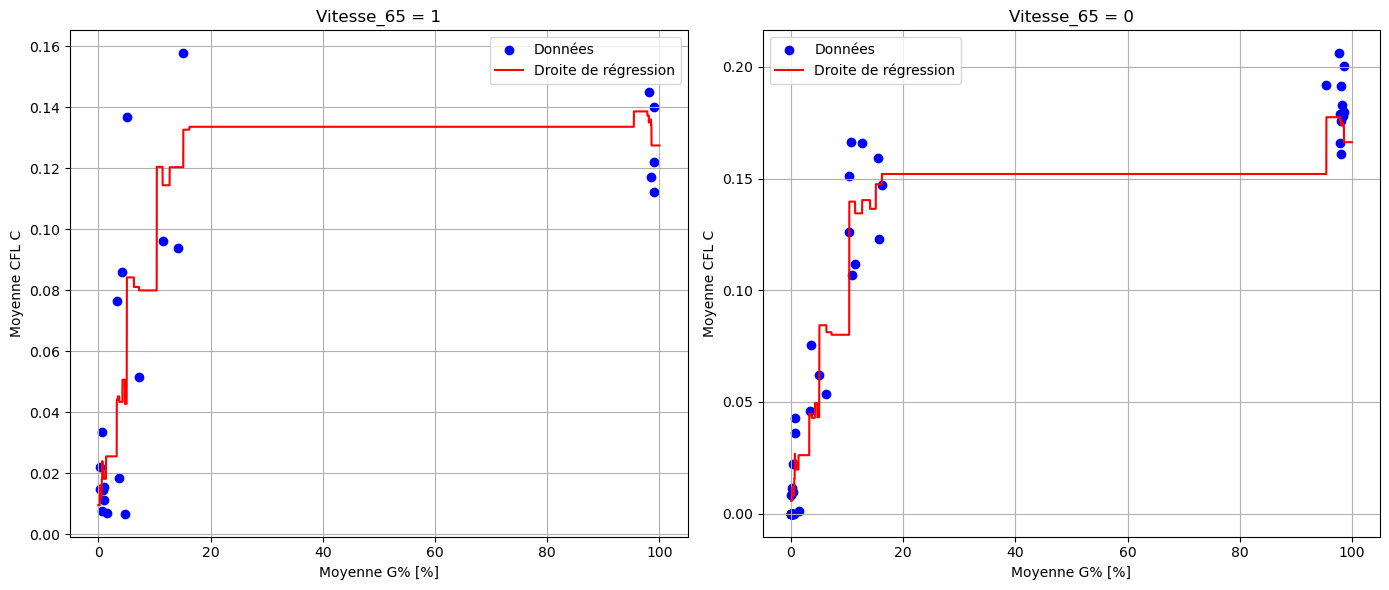

In [71]:
x = np.linspace(0, 100, 10000)
y_v1_regression = model.predict(pd.DataFrame({"glissement" : x, "vitesse_65" : 1}))
y1 = data[data["vitesse"] == "65"]['cflc']
# Calcul de la droite de régression pour Vitesse_65 = 0
y_v0_regression = model.predict(pd.DataFrame({"glissement" : x, "vitesse_65" : 0}))
y0 = data[data["vitesse"] == "40"]['cflc']



# Tracé des graphes
plt.figure(figsize=(14, 6))

# Graphique pour Vitesse_65 = 1
plt.subplot(1, 2, 1)
plt.scatter(X[X['vitesse_65']==1]['glissement'], y1, color='blue', label='Données')
plt.plot(x, y_v1_regression, color='red', label='Droite de régression')
plt.xlabel('Moyenne G% [%]')
plt.ylabel('Moyenne CFL C')
plt.title('Vitesse_65 = 1')
plt.legend()
plt.grid()

# Graphique pour Vitesse_65 = 0
plt.subplot(1, 2, 2)
plt.scatter(X[X['vitesse_65']==0]['glissement'], y0, color='blue', label='Données')
plt.plot(x, y_v0_regression, color='red', label='Droite de régression')
plt.xlabel('Moyenne G% [%]')
plt.ylabel('Moyenne CFL C')
plt.title('Vitesse_65 = 0')
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

## SLUSH

In [74]:
def descritisation_slh(x):
    if x<0.5:
        return "0.5"
    if x<1:
        return "1"
    if x<4:
        return "4"

    elif x< 14:
        return "14"
    else:
        return "more"


In [75]:
data = slh
X = data.drop(['cflc'], axis=1)
X = scale_encode(X,0)
y = data['cflc']




stratify_vitesse = X['vitesse_65']
stratify_glissement = X['glissement'].apply(descritisation_slh)

# Créer une nouvelle colonne de stratification combinée
stratify_combined = stratify_vitesse.astype(str) + '_' + stratify_glissement.astype(str)


In [76]:
%%time
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=stratify_combined, random_state=29)
# Définition des grilles de recherche
param_grid_rf = {
    "random_state" : [2,40,60, 49,0],
    'n_estimators': [30, 40, 80, 100, 120,130],
    'max_depth': [2, 4, 5],
    'min_samples_split': [2,3, 4],
    'min_samples_leaf': [1, 2]
}

param_grid_xgb = {
'n_estimators': [35, 30 ,40,  60, 80, 100],
"random_state" : [2, 42,40,60, 123, 0],
'learning_rate': [0.05, 0.1,0.095, 0.15, 0.001],
'max_depth': [3, 4, 5, 10],
'min_child_weight': [1, 2, 3],
'subsample': [0.7, 0.75,0.8, 1.0],
'colsample_bytree': [0.7, 0.75,0.8, 1.0]
}
# Initialisation de GridSearchCV avec validation croisée stratifiée
cv = KFold(n_splits=5, shuffle=True, random_state=0)
grid_rf = GridSearchCV(estimator=RandomForestRegressor(), param_grid=param_grid_rf, scoring='r2', cv=cv, n_jobs=-1)
grid_xgb = GridSearchCV(estimator=XGBRegressor(), param_grid=param_grid_xgb, scoring='r2', cv=cv, n_jobs=-1)

# Entraînement et évaluation des modèles avec validation croisée stratifiée
models = {
    "Random Forest": grid_rf,
    "XGBoost": grid_xgb
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    best_model = model.best_estimator_
    y_pred = best_model.predict(X_test)
    r2_test = r2_score(y_test, y_pred)
    y_pred_tr = best_model.predict(X_train)
    r2_train = r2_score(y_train, y_pred_tr)       
    results[name] = {
    "Best Params": model.best_params_,
    "R2 (Test)": round(r2_test, 4),
     "R2 (Train)" : round(r2_train, 4)
}


results_df = pd.DataFrame(results).T
print(results)
results_df


{'Random Forest': {'Best Params': {'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 30, 'random_state': 60}, 'R2 (Test)': 0.9394, 'R2 (Train)': 0.9433}, 'XGBoost': {'Best Params': {'colsample_bytree': 0.7, 'learning_rate': 0.095, 'max_depth': 3, 'min_child_weight': 3, 'n_estimators': 80, 'random_state': 2, 'subsample': 0.7}, 'R2 (Test)': 0.911, 'R2 (Train)': 0.9266}}
CPU times: total: 3min 28s
Wall time: 8min 11s


,Best Params,R2 (Test),R2 (Train)
Random Forest,"{'max_depth': 5, 'min_samples_leaf': 2, 'min_s...",0.9394,0.9433
XGBoost,"{'colsample_bytree': 0.7, 'learning_rate': 0.0...",0.911,0.9266


In [77]:
model = RandomForestRegressor(
    max_depth=5,             # Profondeur maximale de l'arbre
    min_samples_leaf=2,      # Nombre minimum d'échantillons par feuille
    min_samples_split=2,     # Nombre minimum d'échantillons pour diviser un nœud
    n_estimators=30,         # Nombre d'arbres dans la forêt
    random_state=60           # État aléatoire pour la reproductibilité
)


# Entraînement et évaluation des modèles
results = {}
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
results[name] = {"RMSE": round(np.sqrt(mse),4), "R2 Score": round(r2,4)}

results_df = pd.DataFrame(results).T
results_df

,R2 Score,RMSE
XGBoost,0.9394,0.0167


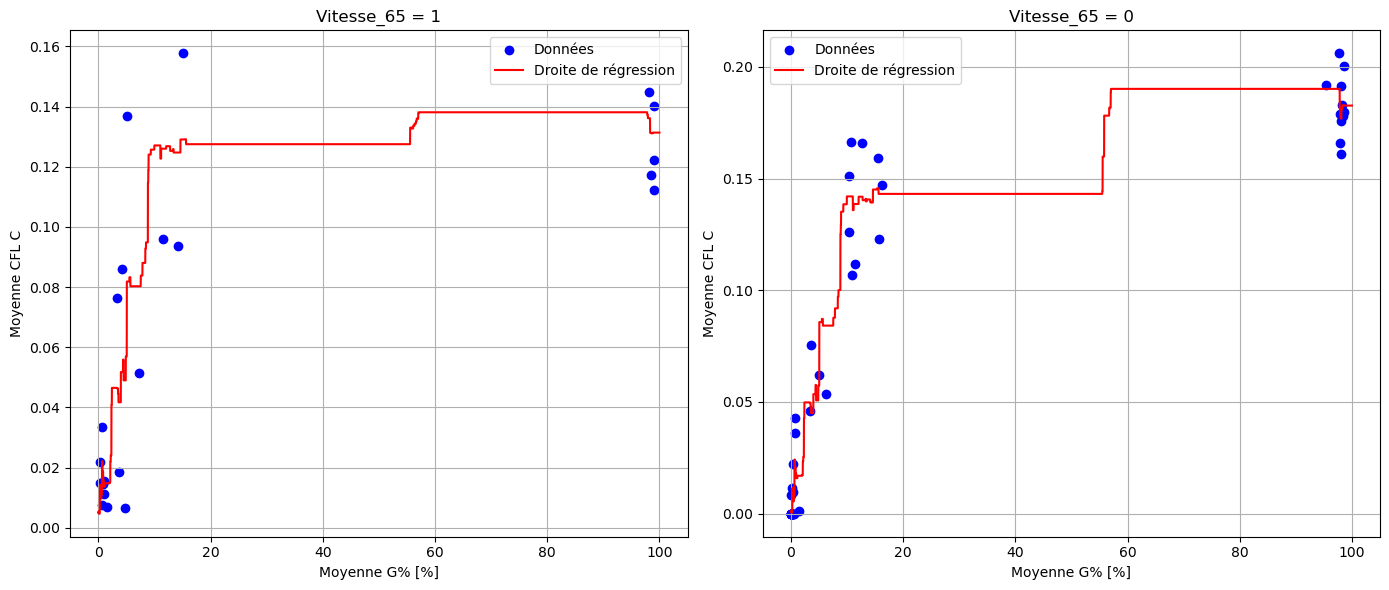

In [78]:
x = np.linspace(0, 100, 10000)
y_v1_regression = model.predict(pd.DataFrame({"glissement" : x, "vitesse_65" : 1}))
y1 = data[data["vitesse"] == "65"]['cflc']
# Calcul de la droite de régression pour Vitesse_65 = 0
y_v0_regression = model.predict(pd.DataFrame({"glissement" : x, "vitesse_65" : 0}))
y0 = data[data["vitesse"] == "40"]['cflc']



# Tracé des graphes
plt.figure(figsize=(14, 6))

# Graphique pour Vitesse_65 = 1
plt.subplot(1, 2, 1)
plt.scatter(X[X['vitesse_65']==1]['glissement'], y1, color='blue', label='Données')
plt.plot(x, y_v1_regression, color='red', label='Droite de régression')
plt.xlabel('Moyenne G% [%]')
plt.ylabel('Moyenne CFL C')
plt.title('Vitesse_65 = 1')
plt.legend()
plt.grid()

# Graphique pour Vitesse_65 = 0
plt.subplot(1, 2, 2)
plt.scatter(X[X['vitesse_65']==0]['glissement'], y0, color='blue', label='Données')
plt.plot(x, y_v0_regression, color='red', label='Droite de régression')
plt.xlabel('Moyenne G% [%]')
plt.ylabel('Moyenne CFL C')
plt.title('Vitesse_65 = 0')
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

In [92]:
RF = [{"contaminant" : 'Neige fraiche (B)','max_depth': 4, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100, 'random_state': 57},
{"contaminant" : 'Neige fraiche (G)','max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 3, 'n_estimators': 30, 'random_state': 49},
{"contaminant" : 'N.C. (G)','max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 30, 'random_state': 60},
{"contaminant" : 'N.C. (B)','max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 3, 'n_estimators': 40, 'random_state': 60},
{"contaminant" : 'NC.C.','max_depth': 4, 'min_samples_leaf': 1, 'min_samples_split': 3, 'n_estimators': 120, 'random_state': 2},
{"contaminant" : 'Verglas','max_depth': 2, 'min_samples_leaf': 1, 'min_samples_split': 4, 'n_estimators': 80, 'random_state': 40},
{"contaminant" : 'Glace','max_depth': 4, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 30, 'random_state': 2},
{"contaminant" : 'SLUSH','max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 30, 'random_state': 60}]
pd.DataFrame(RF)

,contaminant,max_depth,min_samples_leaf,min_samples_split,n_estimators,random_state
0,Neige fraiche (B),4,2,2,100,57
1,Neige fraiche (G),5,1,3,30,49
2,N.C. (G),5,2,2,30,60
3,N.C. (B),5,1,3,40,60
4,NC.C.,4,1,3,120,2
5,Verglas,2,1,4,80,40
6,Glace,4,2,2,30,2
7,SLUSH,5,2,2,30,60


In [91]:
df.Contaminant.unique()

array(['Neige fraiche (B)', 'Neige fraiche (G)', 'N.C. (G)', 'N.C. (B)',
       'NC.C.', 'Verglas', 'DRY', 'Glace', 'SLUSH'], dtype=object)

In [96]:
XGB = [{"contaminant" : 'Neige fraiche (B)', 'colsample_bytree': 1.0, 'learning_rate': 0.05, 'max_depth': 5, 'min_child_weight': 2, 'n_estimators': 80, 'random_state': 76, 'subsample': 0.8},
{"contaminant" : 'Neige fraiche (G)','colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 5, 'min_child_weight': 2, 'n_estimators': 30, 'random_state': 49, 'subsample': 0.8},
{"contaminant" : 'N.C. (G)','colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 5, 'min_child_weight': 2, 'n_estimators': 30, 'random_state': 42, 'subsample': 0.7},
{"contaminant" : 'N.C. (B)','colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 5, 'min_child_weight': 2, 'n_estimators': 30, 'random_state': 60, 'subsample': 0.8},
{"contaminant" : 'NC.C.','colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 5, 'min_child_weight': 2, 'n_estimators': 30, 'random_state': 2, 'subsample': 0.7},
{"contaminant" : 'Verglas','colsample_bytree': 1.0, 'learning_rate': 0.095, 'max_depth': 5, 'min_child_weight': 1, 'n_estimators': 35, 'random_state': 42, 'subsample': 0.7},
{"contaminant" : 'Glace','colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 4, 'min_child_weight': 3, 'n_estimators': 30, 'random_state': 60, 'subsample': 0.7},
{"contaminant" : 'SLUSH','colsample_bytree': 0.7, 'learning_rate': 0.095, 'max_depth': 3, 'min_child_weight': 3, 'n_estimators': 80, 'random_state': 2, 'subsample': 0.7}]
pd.DataFrame(XGB)

,contaminant,colsample_bytree,learning_rate,max_depth,min_child_weight,n_estimators,random_state,subsample
0,Neige fraiche (B),1.0,0.050,5,2,80,76,0.8
1,Neige fraiche (G),1.0,0.100,5,2,30,49,0.8
2,N.C. (G),1.0,0.100,5,2,30,42,0.7
3,N.C. (B),1.0,0.100,5,2,30,60,0.8
4,NC.C.,1.0,0.100,5,2,30,2,0.7
5,Verglas,1.0,0.095,5,1,35,42,0.7
6,Glace,1.0,0.100,4,3,30,60,0.7
7,SLUSH,0.7,0.095,3,3,80,2,0.7


In [100]:
Result =[{"contaminant" : 'Neige fraiche (B)', "R² test (XGBoost)": 0.854, "R² test (Random Forest)" : 0.8354},
{"contaminant" : 'Neige fraiche (G)', "R² test (XGBoost)" : 0.9323, "R² test (Random Forest)" : 0.9315},
{"contaminant" : 'N.C. (G)', "R² test (XGBoost)" : 0.935, "R² test (Random Forest)" : 0.9185},
{"contaminant" : 'N.C. (B)', "R² test (XGBoost)" : 0.9022, "R² test (Random Forest)" : 0.9235},
{"contaminant" : 'NC.C.', "R² test (XGBoost)" : 0.9151, "R² test (Random Forest)" : 0.9236},
{"contaminant" : 'Verglas', "R² test (XGBoost)" : 0.8411, "R² test (Random Forest)" : 0.8349},
{"contaminant" : 'Glace', "R² test (XGBoost)" : 0.9451, "R² test (Random Forest)" : 0.9442},
{"contaminant" : 'SLUSH', "R² test (XGBoost)" : 0.911, "R² test (Random Forest)" : 0.9394}]
pd.DataFrame(Result)

,contaminant,R² test (XGBoost),R² test (Random Forest)
0,Neige fraiche (B),0.8540,0.8354
1,Neige fraiche (G),0.9323,0.9315
2,N.C. (G),0.9350,0.9185
3,N.C. (B),0.9022,0.9235
4,NC.C.,0.9151,0.9236
5,Verglas,0.8411,0.8349
6,Glace,0.9451,0.9442
7,SLUSH,0.9110,0.9394


'R²'